# mpg

In [1]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
import os
import random
import numpy as np

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
#    torch.manual_seed(seed)
#    torch.cuda.manual_seed(seed)
#    torch.backends.cudnn.deterministic = True
#    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [3]:
df = sns.load_dataset('mpg')

In [4]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [5]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [6]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger
397,31.0,4,119.0,82.0,2720,19.4,82,usa,chevy s-10


In [7]:
print(df.shape)

(398, 9)


In [8]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [10]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [13]:
print(df.origin.unique())

['usa' 'japan' 'europe']


In [14]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

dfi = df.copy()

dfi['origin'] = label_encoder.fit_transform(dfi['origin'])
print(label_encoder.classes_)

['europe' 'japan' 'usa']


In [15]:
dfi.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,2,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,2,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,2,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,2,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,2,ford torino


In [16]:
dfi.drop('name', axis=1, inplace=True)

In [17]:
dfi.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,2
1,15.0,8,350.0,165.0,3693,11.5,70,2
2,18.0,8,318.0,150.0,3436,11.0,70,2
3,16.0,8,304.0,150.0,3433,12.0,70,2
4,17.0,8,302.0,140.0,3449,10.5,70,2


In [18]:
y_data = dfi[['mpg']].values
dfi.drop('mpg', axis=1, inplace=True)
X_data = dfi.values

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2) # train과 test를 8:2로 분할

In [20]:
import xgboost as xgb ## XGBoost 불러오기
from xgboost import plot_importance ## Feature Importance를 불러오기 위함

In [21]:
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.08, gamma=0, subsample=0.75,
                           colsample_bytree=1, max_depth=7)

In [22]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [23]:
y = model.predict(X_train)

In [24]:
print(y.shape)
print(y_train.shape)

(313,)
(313, 1)


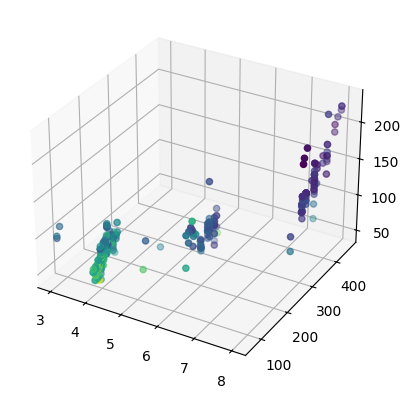

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2], c = y_train.reshape(-1))
plt.show()

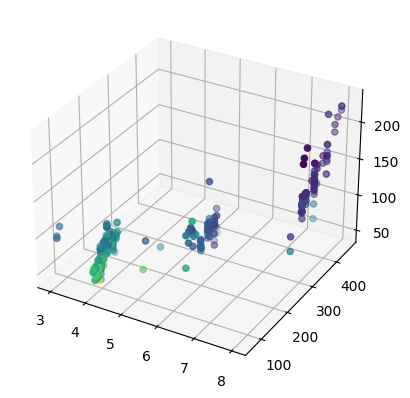

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2], c = y)
plt.show()

In [27]:
print(model.score(X_train, y_train))

0.9984416052144323


In [28]:
print(model.score(X_test, y_test))

0.8709265811018845


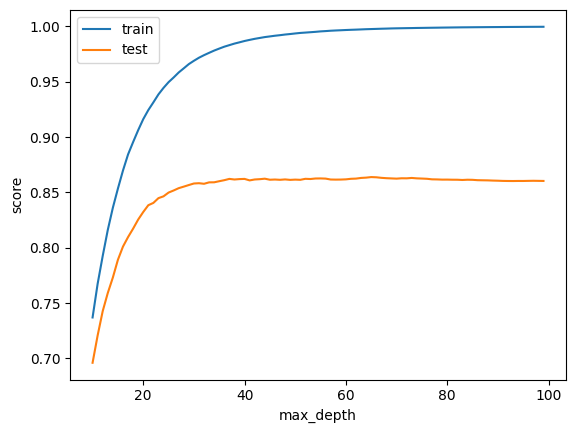

In [29]:
train_score = []
test_score = []
n_range = range(10, 100)

for n in n_range:
    model = xgb.XGBRegressor(n_estimators=n, learning_rate=0.08, gamma=0, subsample=0.75,
                           colsample_bytree=1, max_depth=10)
    model.fit(X_train, y_train)
    train_score.append(model.score(X_train, y_train))
    test_score.append(model.score(X_test, y_test))

plt.figure()
plt.plot(n_range, train_score, label='train')
plt.plot(n_range, test_score, label='test')
plt.legend()
plt.xlabel('max_depth')
plt.ylabel('score')
plt.show()

In [30]:
from sklearn import metrics

y_pred = model.predict(X_test)
print('mean_absolute_error: ', metrics.mean_absolute_error(y_test, y_pred)) # best는 0.0
print('mean_squared_error: ', metrics.mean_squared_error(y_test, y_pred)) # best는 0.0
print(f'MAPE: ', metrics.mean_absolute_percentage_error(y_test, y_pred) * 100) # best는 0.0%
print('r2_score: ', metrics.r2_score(y_test, y_pred)) # best는 1.0

mean_absolute_error:  1.7937623422357103
mean_squared_error:  7.129168976082351
MAPE:  8.100006633938246
r2_score:  0.8603235205487603
